In [28]:
#import all the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

pd.pandas.set_option('display.max_columns',None)  #to always display all the columns present

In [29]:
dataset=pd.read_csv('Loanapproval.csv')

In [30]:
# print shape of dataset with rows and columns
print(dataset.shape)

(614, 13)


In [31]:
# print the top5 records
dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


**Exploratory data analysis**

    

*   Missing Values
*   Numerical Variables
*   Distribution of the Numerical Variables
*   Categorical Variables
*   Cardinality of Categorical Variables
*   Outliers
*   Relationship between independent and dependent  
    
    
    







**Missing Values**

In [38]:
# Here we will check the percentage of nan values present in each feature
## Step-1 make the list of features which has missing values
features_with_na=[features for features in dataset.columns if dataset[features].isnull().sum()>1]
## Step-2 print the feature name and the percentage of missing values
for feature in features_with_na:
    print(feature, 'has', np.round(dataset[feature].isnull().mean(), 4), '% missing values.')

Gender has 0.0212 % missing values.
Married has 0.0049 % missing values.
Dependents has 0.0244 % missing values.
Self_Employed has 0.0521 % missing values.
LoanAmount has 0.0358 % missing values.
Loan_Amount_Term has 0.0228 % missing values.
Credit_History has 0.0814 % missing values.


**Numerical Variables**

In [12]:
# list of numerical variables
numerical_features = [feature for feature in dataset.columns if dataset[feature].dtypes != 'O']

print('Number of numerical variables: ', len(numerical_features))

# visualise the numerical variables
dataset[numerical_features].head()

Number of numerical variables:  5


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,5849,0.0,NaN,360.0,1.0
1,4583,1508.0,128.0,360.0,1.0
2,3000,0.0,66.0,360.0,1.0
3,2583,2358.0,120.0,360.0,1.0
4,6000,0.0,141.0,360.0,1.0


Text(0.5, 1.0, 'income vs loan')

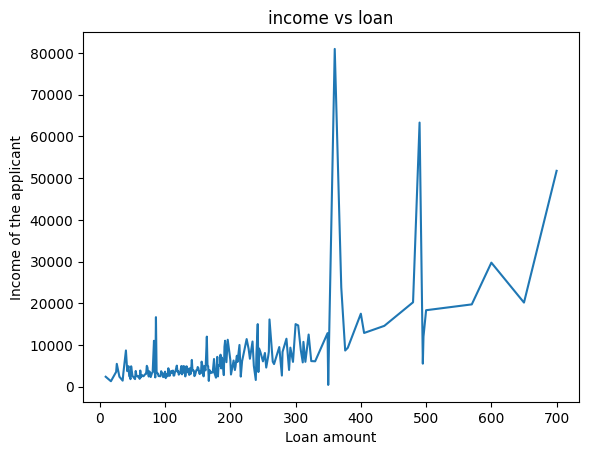

In [39]:
## We will check whether there is a relation between the Loan Amount approved and the Applicant's Income
dataset.groupby('LoanAmount')['ApplicantIncome'].median().plot()
plt.xlabel('Loan amount')
plt.ylabel('Income of the applicant')
plt.title("income vs loan")

**Numerical variables are usually of 2 type**


1.   Discrete variables
2.   Continous Variables



In [40]:
# 1. Discrete variables
discrete_feature=[feature for feature in numerical_features if len(dataset[feature].unique())<25 and feature not in year_feature+['Id']]
print("Discrete Variables Count: {}".format(len(discrete_feature)))

Discrete Variables Count: 2


In [16]:
discrete_feature

['Loan_Amount_Term', 'Credit_History']

In [17]:
dataset[discrete_feature].head()

,Loan_Amount_Term,Credit_History
0,360.0,1.0
1,360.0,1.0
2,360.0,1.0
3,360.0,1.0
4,360.0,1.0


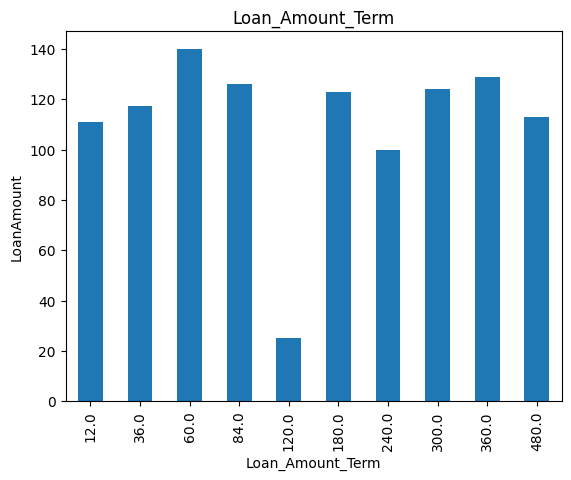

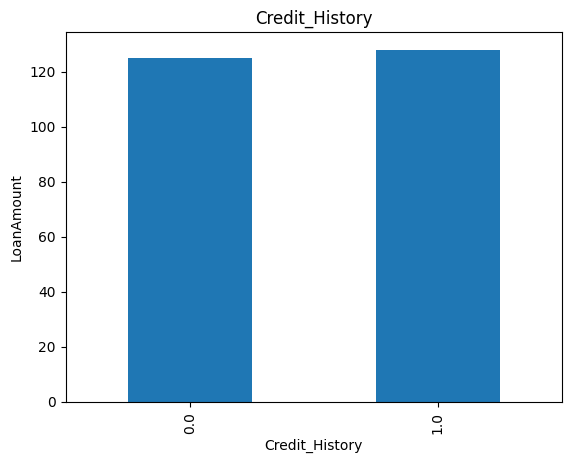

In [18]:
## The realtionship between discrete variables and Loan Amount
for feature in discrete_feature:
    data=dataset.copy()
    data.groupby(feature)['LoanAmount'].median().plot.bar()
    plt.xlabel(feature)
    plt.ylabel('LoanAmount')
    plt.title(feature)
    plt.show()

In [19]:
# 2.Continuous Variables
continuous_feature=[feature for feature in numerical_features if feature not in discrete_feature+year_feature+['Id']]
print("Continuous feature Count {}".format(len(continuous_feature)))

Continuous feature Count 3


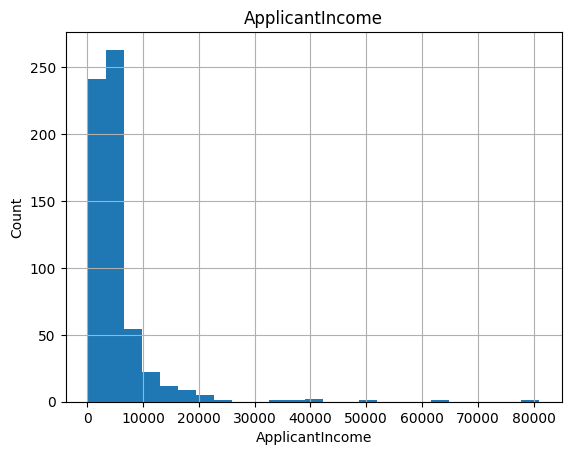

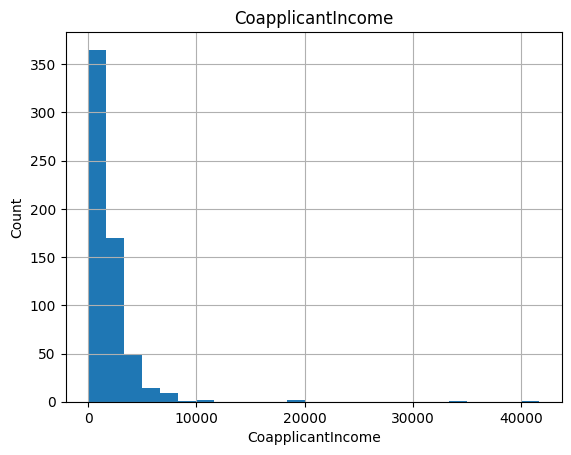

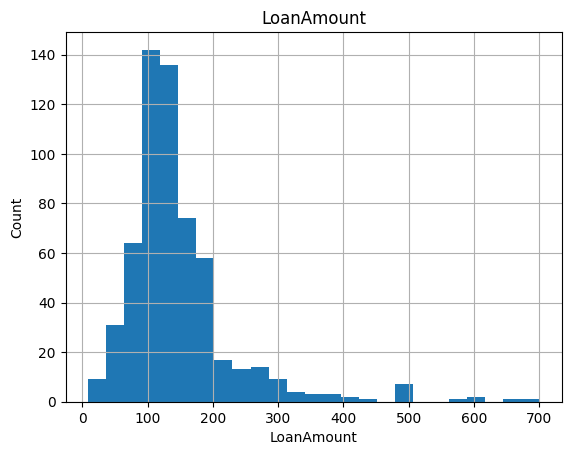

In [20]:
## Lets analyse the continuous values by creating histograms to understand the distribution
for feature in continuous_feature:
    data=dataset.copy()
    data[feature].hist(bins=25)
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.title(feature)
    plt.show()

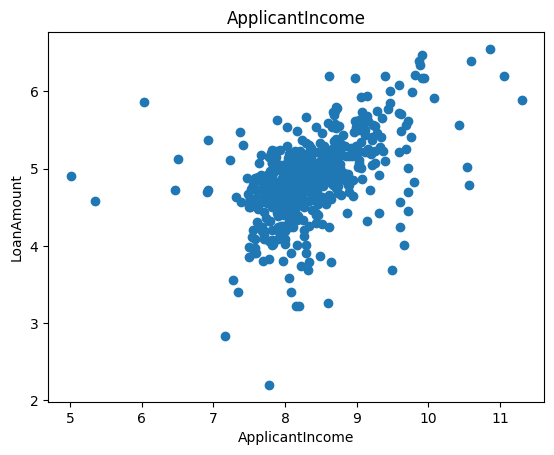

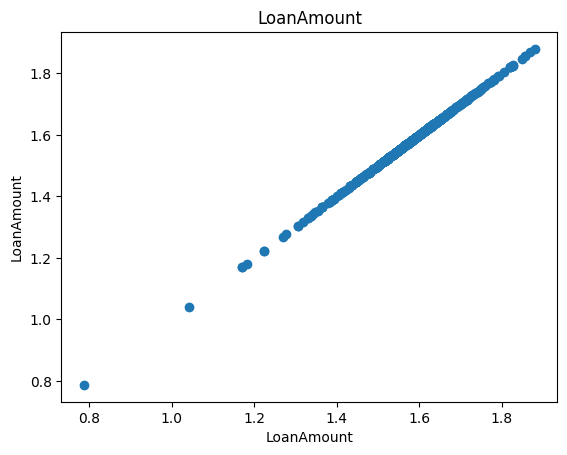

In [21]:
## We will be using logarithmic transformation
for feature in continuous_feature:
    data=dataset.copy()
    if 0 in data[feature].unique():
        pass
    else:
        data[feature]=np.log(data[feature])
        data['LoanAmount']=np.log(data['LoanAmount'])
        plt.scatter(data[feature],data['LoanAmount'])
        plt.xlabel(feature)
        plt.ylabel('LoanAmount')
        plt.title(feature)
        plt.show()

**Categorical Variables**

In [23]:
categorical_features=[feature for feature in dataset.columns if data[feature].dtypes=='O']
categorical_features

['Loan_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Property_Area',
 'Loan_Status']

In [24]:
dataset[categorical_features].head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,Urban,Y
4,LP001008,Male,No,0,Graduate,No,Urban,Y


In [25]:
for feature in categorical_features:
    print('The feature is {} and number of categories are {}'.format(feature,len(dataset[feature].unique())))

The feature is Loan_ID and number of categories are 614
The feature is Gender and number of categories are 3
The feature is Married and number of categories are 3
The feature is Dependents and number of categories are 5
The feature is Education and number of categories are 2
The feature is Self_Employed and number of categories are 3
The feature is Property_Area and number of categories are 3
The feature is Loan_Status and number of categories are 2


**Outliers**

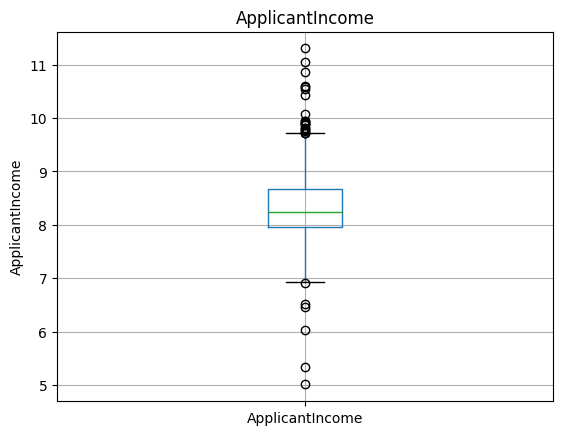

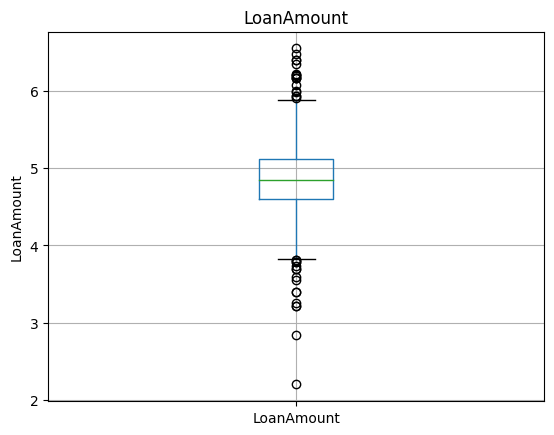

In [22]:
for feature in continuous_feature:
    data=dataset.copy()
    if 0 in data[feature].unique():
        pass
    else:
        data[feature]=np.log(data[feature])
        data.boxplot(column=feature)
        plt.ylabel(feature)
        plt.title(feature)
        plt.show()


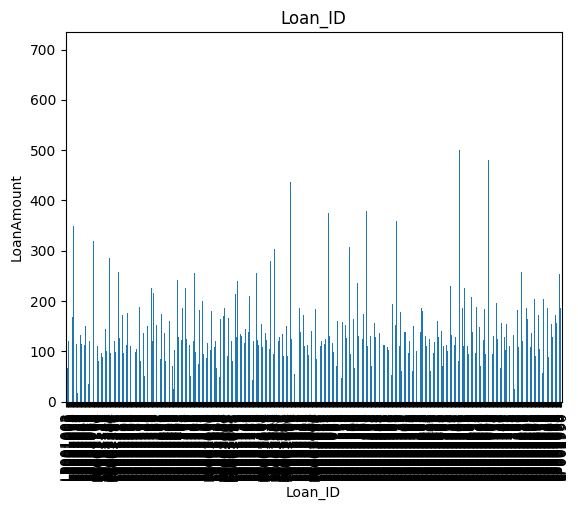

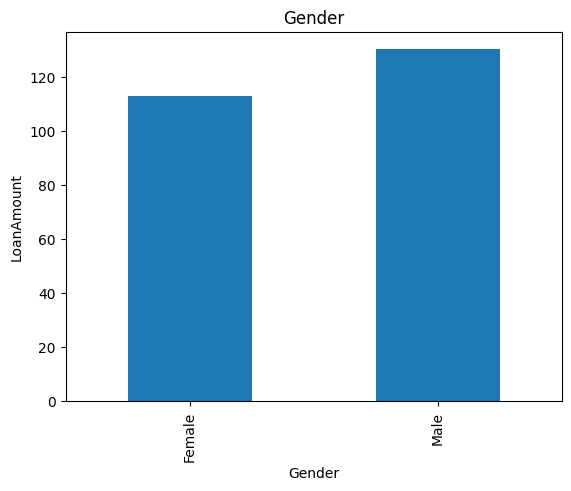

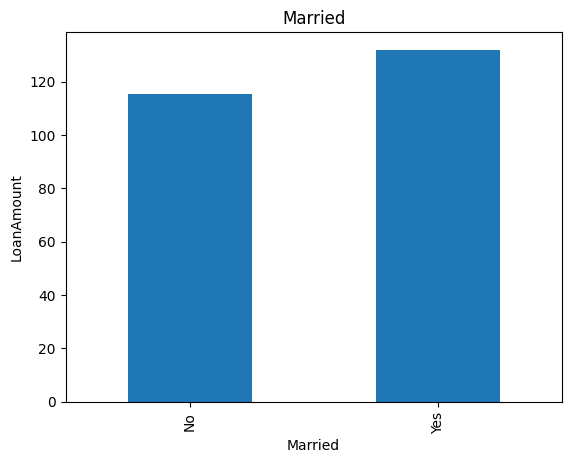

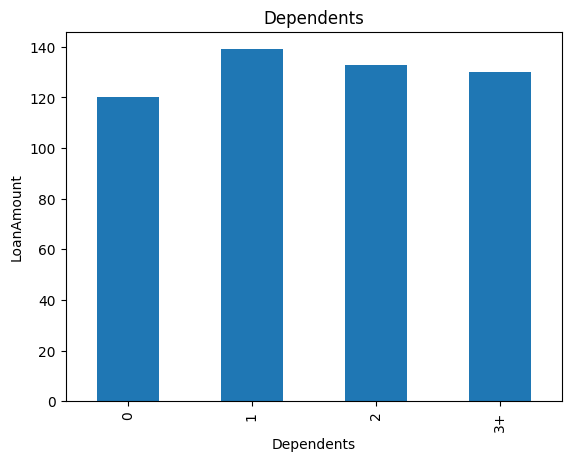

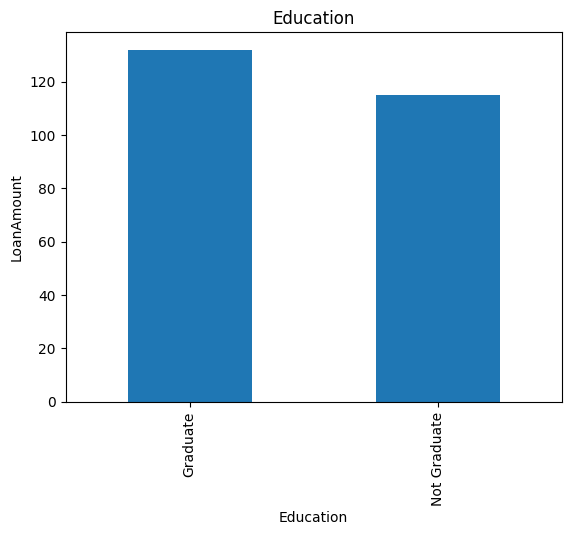

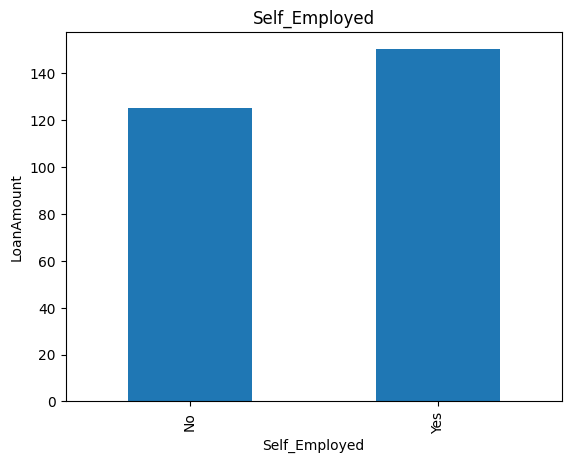

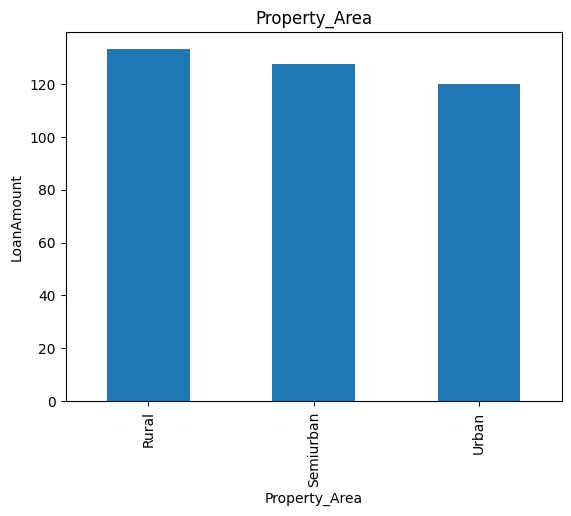

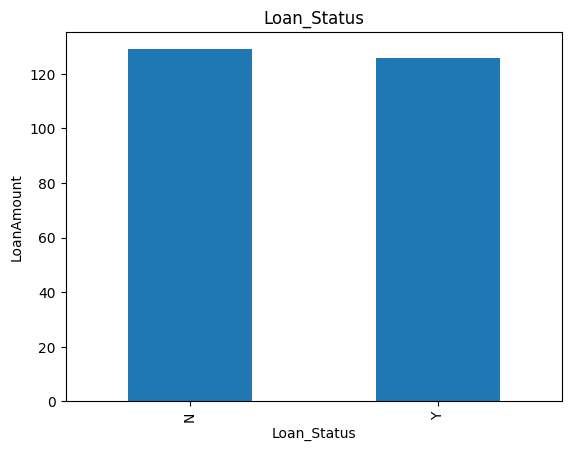

In [26]:
## Find out the relationship between categorical variable and dependent feature Loan Amount
for feature in categorical_features:
    data=dataset.copy()
    data.groupby(feature)['LoanAmount'].median().plot.bar()
    plt.xlabel(feature)
    plt.ylabel('LoanAmount')
    plt.title(feature)
    plt.show()